In [1]:
import sys
sys.path.append('/mnt/scratch/scheduler/proxy_server')
from plot_functions import *
import os

# Default

In [2]:
import os
import glob
import json
import re
import pandas as pd
import matplotlib.pyplot as plt

def extrair_metricas_json(pasta, metrica="total_e2el_s"):
    padrao_busca = os.path.join(pasta, "baseline_output_fcfs_autellix_rateinf_*progs_run1.json")
    arquivos = glob.glob(padrao_busca)
    
    dados_tabela = []
    
    for arquivo in arquivos:
        nome_arquivo = os.path.basename(arquivo)
        match = re.search(r"rateinf_(\d+)progs_run1\.json", nome_arquivo)
        
        if not match:
            continue
            
        num_programas = int(match.group(1))
        
        with open(arquivo, 'r', encoding='utf-8') as f:
            try:
                conteudo = json.load(f)
                
                # ========================================================
                # NOVO: PROCESSAMENTO DO ARQUIVO CSV (KV CACHE)
                # ========================================================
                # Substitui a extensão para encontrar o CSV correspondente
                arquivo_csv = arquivo.replace(".json", "_kv_cache.csv")
                
                if os.path.exists(arquivo_csv):
                    # Lê o CSV usando pandas
                    df_csv = pd.read_csv(arquivo_csv)
                    
                    # Filtra os valores de kv_cache_percent ignorando os 0.0
                    kv_ativos = df_csv[df_csv['kv_cache_percent'] > 0.0]['kv_cache_percent']
                    
                    # Se houver dados válidos no CSV, calcula e injeta no dicionário 'full_metrics'
                    if not kv_ativos.empty:
                        if "full_metrics" not in conteudo:
                            conteudo["full_metrics"] = {}
                            
                        # Adiciona as métricas calculadas na memória
                        conteudo["full_metrics"]["kv_cache_mean"] = kv_ativos.mean()
                        conteudo["full_metrics"]["kv_cache_median"] = kv_ativos.median()
                        conteudo["full_metrics"]["kv_cache_p75"] = kv_ativos.quantile(0.75)
                        conteudo["full_metrics"]["kv_cache_p90"] = kv_ativos.quantile(0.90)
                        conteudo["full_metrics"]["kv_cache_p95"] = kv_ativos.quantile(0.95)
                        conteudo["full_metrics"]["kv_cache_p99"] = kv_ativos.quantile(0.99)
                # ========================================================
                
                # Lógica especial para o hit_rate do prefix_cache
                if metrica == "prefix_cache_hit_rate":
                    prefix_cache = conteudo.get("full_metrics", {}).get("prefix_cache", {})
                    if prefix_cache:
                        primeiro_engine = list(prefix_cache.keys())[0]
                        valor_metrica = prefix_cache[primeiro_engine].get("hit_rate", None)
                    else:
                        valor_metrica = None
                
                # Lógica padrão para as demais métricas (INCLUINDO AS NOVAS DO KV CACHE)
                else:
                    valor_metrica = conteudo.get("full_metrics", {}).get(metrica, None)
                
                if valor_metrica is not None:
                    dados_tabela.append({
                        "num_programs": num_programas,
                        metrica: valor_metrica
                    })
                else:
                    print(f"Aviso: Métrica '{metrica}' não encontrada para {nome_arquivo}.")
                    
            except Exception as e:
                print(f"Erro ao processar {nome_arquivo}: {e}")
                
    df = pd.DataFrame(dados_tabela)
    if not df.empty:
        df = df.sort_values(by="num_programs").reset_index(drop=True)
        
    return df

def plotar_metricas_json(pasta, metrica="total_e2el_s"):
    df = extrair_metricas_json(pasta, metrica)
    
    if df.empty:
        print(f"Nenhum dado encontrado na pasta '{pasta}' para a métrica '{metrica}'.")
        return
    
    plt.figure(figsize=(10, 6))
    plt.scatter(df["num_programs"], df[metrica], color="#1f77b4", marker="o", s=100, zorder=3)
    
    plt.title(f"Impacto do Número de Programas na Métrica: {metrica}", fontsize=14, pad=15)
    plt.xlabel("Número de Programas (num_programs)", fontsize=12)
    plt.ylabel(metrica, fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.7, zorder=0)
    
    plt.xlim(df["num_programs"].min() - 1, df["num_programs"].max() + 1)
    
    plt.tight_layout()
    plt.show()

In [3]:
import os
import glob
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np  # Necessário para a regressão linear

# (Mantenha a função extrair_metricas_json que criamos no passo anterior)

def plotar_regressao(pasta, metrica="total_e2el_s"):
    """
    Lê arquivos JSON, exibe um gráfico de pontos e plota uma regressão linear 
    calculada com pontos < 350, mas estendida por todo o eixo X do gráfico.
    """
    df = extrair_metricas_json(pasta, metrica)
    
    if df.empty:
        print(f"Nenhum dado encontrado na pasta '{pasta}' para a métrica '{metrica}'.")
        return
    
    plt.figure(figsize=(10, 6))
    
    # Plota todos os pontos (dispersão geral)
    plt.scatter(df["num_programs"], df[metrica], color="#1f77b4", marker="o", s=100, zorder=3, label="Métricas executadas")
    
    # Filtra os dados para calcular a regressão APENAS com num_programs < 350
    df_filtrado = df[df["num_programs"] < 350]
    
    if len(df_filtrado) > 1:
        x_treino = df_filtrado["num_programs"]
        y_treino = df_filtrado[metrica]
        
        # Calcula a regressão linear (polinômio de grau 1) com os dados filtrados
        coeficientes = np.polyfit(x_treino, y_treino, 1)
        polinomio = np.poly1d(coeficientes)
        
        # GERA A LINHA PARA TODA A EXTENSÃO: Usa o min e max do DataFrame original (df)
        x_linha = np.linspace(df["num_programs"].min(), df["num_programs"].max(), 100)
        y_linha = polinomio(x_linha)
        
        # Plota a linha vermelha tracejada projetada
        plt.plot(x_linha, y_linha, color="red", linestyle="--", linewidth=2.5, zorder=4,
                 label=f"Projeção da Tendência (<350)\ny = {coeficientes[0]:.4g}x + {coeficientes[1]:.4g}")
    elif len(df_filtrado) == 1:
        print("Aviso: Apenas 1 ponto encontrado abaixo de 350 programas. Regressão linear impossível.")
    else:
        print("Aviso: Nenhum ponto encontrado abaixo de 350 programas.")

    # Estilização
    plt.title(f"Impacto do Número de Programas na Métrica: {metrica}", fontsize=14, pad=15)
    plt.xlabel("Número de Programas (num_programs)", fontsize=12)
    plt.ylabel(metrica, fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.7, zorder=0)
    plt.legend(fontsize=10)
    
    plt.xlim(df["num_programs"].min() - 1, df["num_programs"].max() + 1)
    
    plt.tight_layout()
    plt.show()

In [4]:
import os
import glob
import json

def recalcular_throughput_nos_jsons(pasta):
    """
    Lê os arquivos JSON, recalcula os throughputs de tokens (input, output e total)
    baseado no tempo 'total_e2el_s' e salva a alteração diretamente no próprio arquivo.
    """
    padrao_busca = os.path.join(pasta, "baseline_output_fcfs_autellix_rateinf_*progs_run1.json")
    arquivos = glob.glob(padrao_busca)
    
    arquivos_atualizados = 0
    
    for arquivo in arquivos:
        nome_arquivo = os.path.basename(arquivo)
        
        # 1. Lê o conteúdo atual do JSON
        with open(arquivo, 'r', encoding='utf-8') as f:
            try:
                conteudo = json.load(f)
            except json.JSONDecodeError:
                print(f"Erro ao ler o arquivo {nome_arquivo}. JSON inválido.")
                continue
                
        # 2. Verifica se a chave 'full_metrics' existe
        if "full_metrics" in conteudo:
            fm = conteudo["full_metrics"]
            chaves_necessarias = ["total_input_tokens", "total_output_tokens", "total_e2el_s"]
            
            # Garante que os dados necessários para o cálculo estão presentes
            if all(k in fm for k in chaves_necessarias):
                in_tokens = fm["total_input_tokens"]
                out_tokens = fm["total_output_tokens"]
                tempo_total = fm["total_e2el_s"]
                
                # Previne erro de divisão por zero
                if tempo_total > 0:
                    # Faz os recálculos
                    in_throughput = in_tokens / tempo_total
                    out_throughput = out_tokens / tempo_total
                    total_throughput = (in_tokens + out_tokens) / tempo_total
                    
                    # Substitui/Adiciona os valores no dicionário
                    conteudo["full_metrics"]["input_token_throughput"] = in_throughput
                    conteudo["full_metrics"]["output_token_throughput"] = out_throughput
                    conteudo["full_metrics"]["total_token_throughput"] = total_throughput
                    
                    # 3. Salva as alterações de volta no arquivo original
                    with open(arquivo, 'w', encoding='utf-8') as f_out:
                        # indent=2 mantém o arquivo legível e formatado bonitinho
                        json.dump(conteudo, f_out, indent=2, ensure_ascii=False)
                        
                    print(f"Atualizado: {nome_arquivo}")
                    arquivos_atualizados += 1
                else:
                    print(f"Ignorado: {nome_arquivo} (total_e2el_s é zero ou negativo)")
            else:
                print(f"Ignorado: {nome_arquivo} (faltam chaves base para o cálculo)")
        else:
            print(f"Ignorado: {nome_arquivo} (sem chave 'full_metrics')")
            
    print(f"\nProcesso concluído! {arquivos_atualizados} arquivos foram atualizados.")

In [6]:
recalcular_throughput_nos_jsons("var_50it_nosleep")

Atualizado: baseline_output_fcfs_autellix_rateinf_190progs_run1.json
Atualizado: baseline_output_fcfs_autellix_rateinf_266progs_run1.json
Atualizado: baseline_output_fcfs_autellix_rateinf_228progs_run1.json
Atualizado: baseline_output_fcfs_autellix_rateinf_76progs_run1.json
Atualizado: baseline_output_fcfs_autellix_rateinf_152progs_run1.json
Atualizado: baseline_output_fcfs_autellix_rateinf_608progs_run1.json
Atualizado: baseline_output_fcfs_autellix_rateinf_342progs_run1.json
Atualizado: baseline_output_fcfs_autellix_rateinf_456progs_run1.json
Atualizado: baseline_output_fcfs_autellix_rateinf_304progs_run1.json
Atualizado: baseline_output_fcfs_autellix_rateinf_380progs_run1.json
Atualizado: baseline_output_fcfs_autellix_rateinf_418progs_run1.json
Atualizado: baseline_output_fcfs_autellix_rateinf_494progs_run1.json
Atualizado: baseline_output_fcfs_autellix_rateinf_19progs_run1.json
Atualizado: baseline_output_fcfs_autellix_rateinf_38progs_run1.json
Atualizado: baseline_output_fcfs_aute

In [7]:
tabela_e2el = extrair_metricas_json("var_50it_nosleep")
print(tabela_e2el)


    num_programs  total_e2el_s
0             19    232.737803
1             38    214.275689
2             76    478.650241
3            114    696.103679
4            152   1020.174017
5            190   1291.954709
6            228   1759.724559
7            266   2033.894832
8            304   2381.740251
9            342   2864.534344
10           380   3322.407648
11           418   3929.665574
12           456   4944.848207
13           494   6145.139970
14           532   6553.885198
15           570   7853.466703
16           608   8439.634088


In [8]:
# tabela_tokens = extrair_metricas_json("var_50it", metrica="mean_e2el_per_program")
tabela_tokens = extrair_metricas_json("var_50it_nosleep", metrica="prefix_cache_hit_rate")
print(tabela_tokens)

    num_programs  prefix_cache_hit_rate
0             19               0.965692
1             38               0.967604
2             76               0.966798
3            114               0.963867
4            152               0.964816
5            190               0.961183
6            228               0.958952
7            266               0.953625
8            304               0.951556
9            342               0.946707
10           380               0.948645
11           418               0.945706
12           456               0.941401
13           494               0.934623
14           532               0.934936
15           570               0.932298
16           608               0.928103


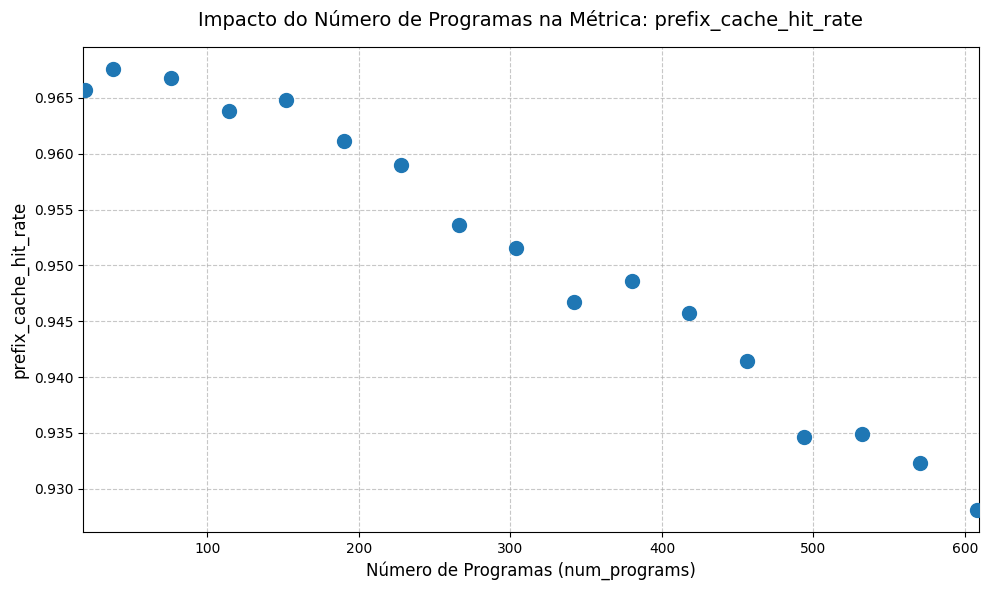

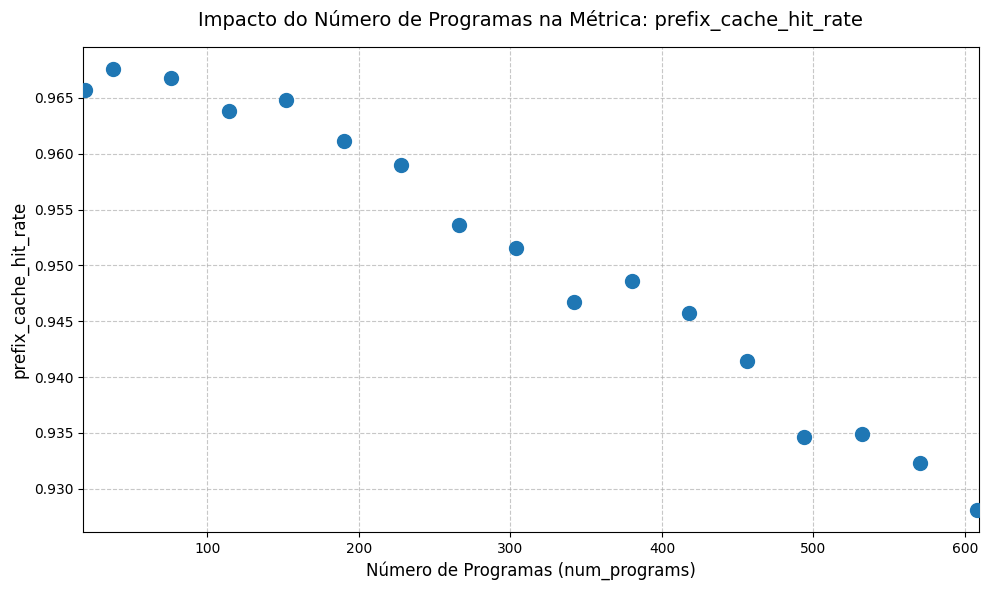

In [9]:
plotar_metricas_json("var_50it_nosleep", metrica="prefix_cache_hit_rate")
plotar_metricas_json("var_50it_nosleep", metrica="prefix_cache_hit_rate")

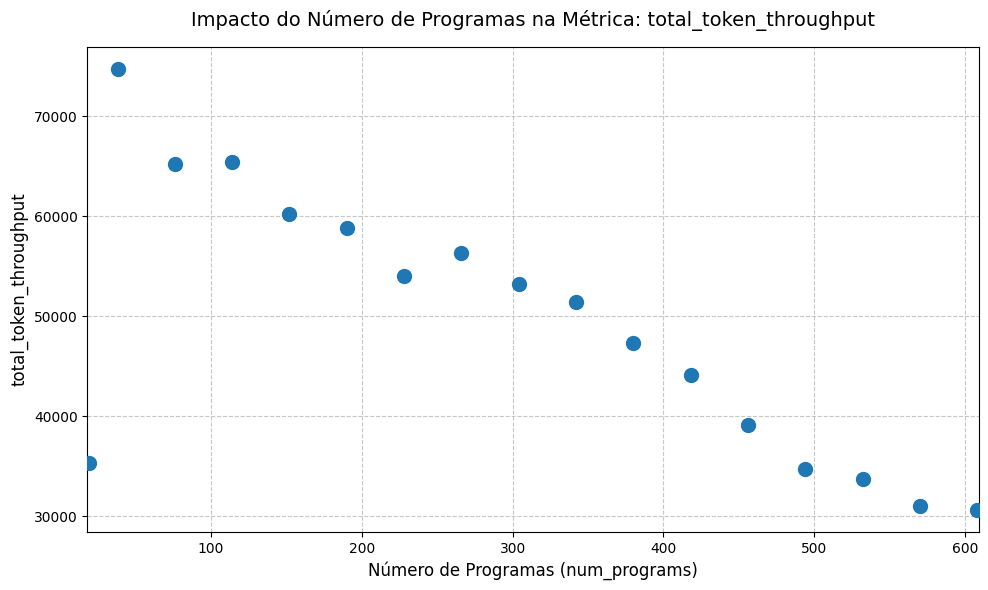

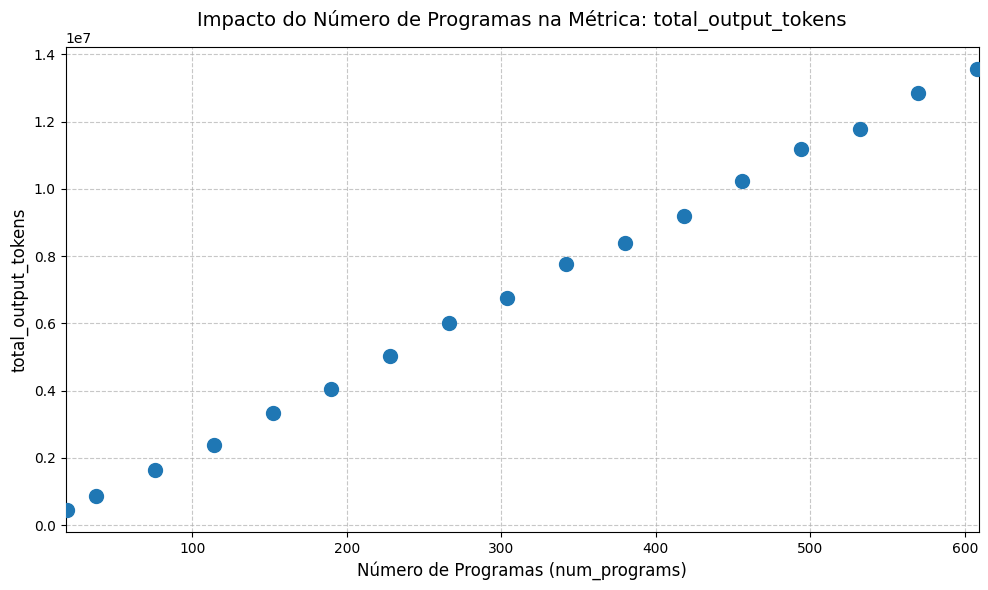

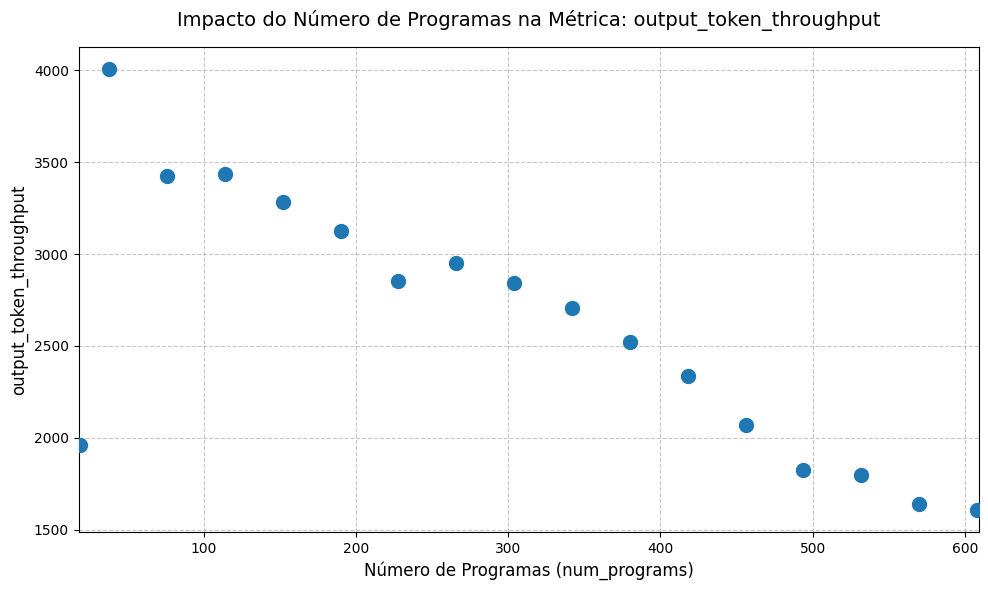

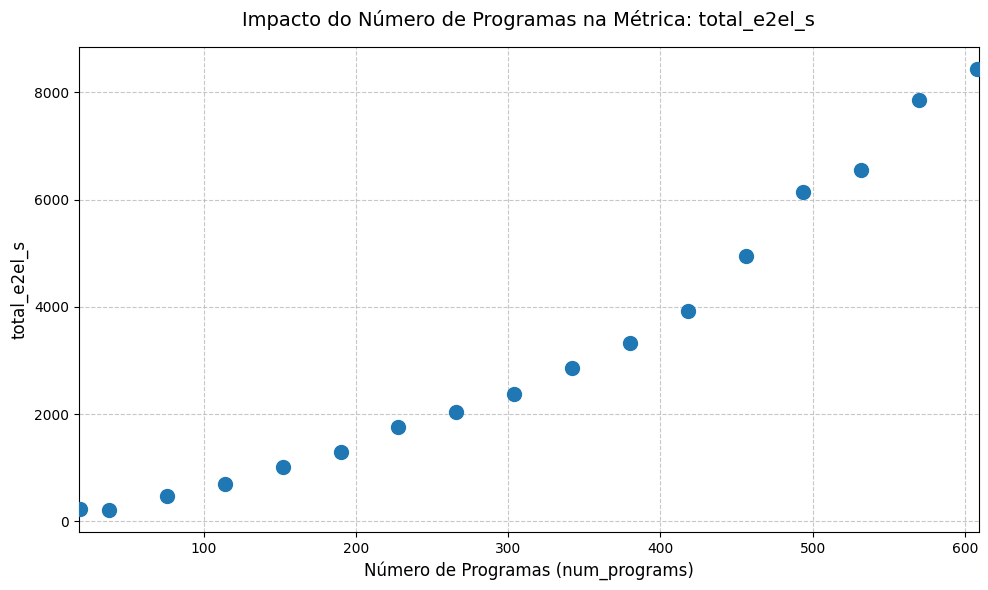

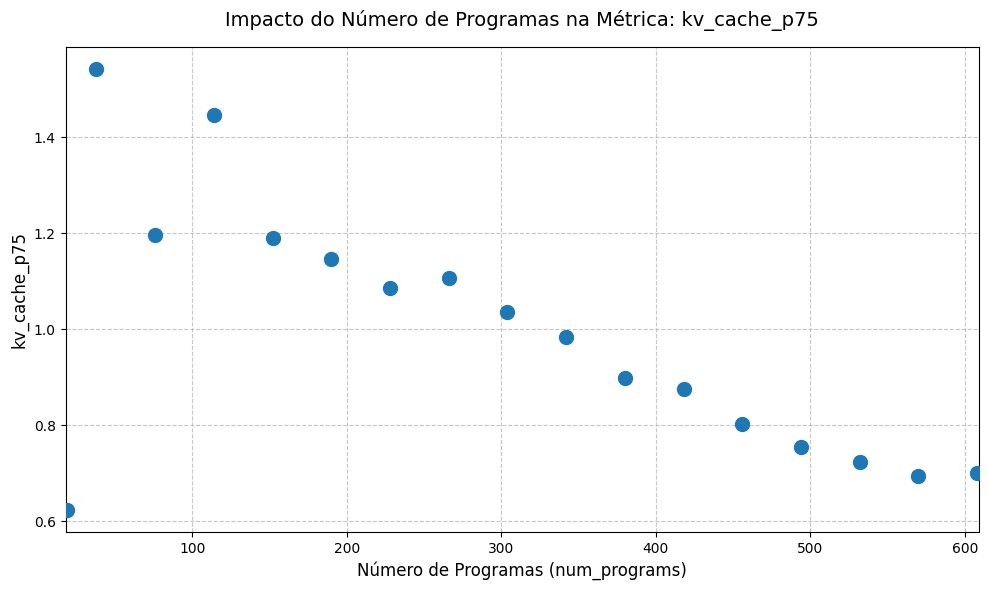

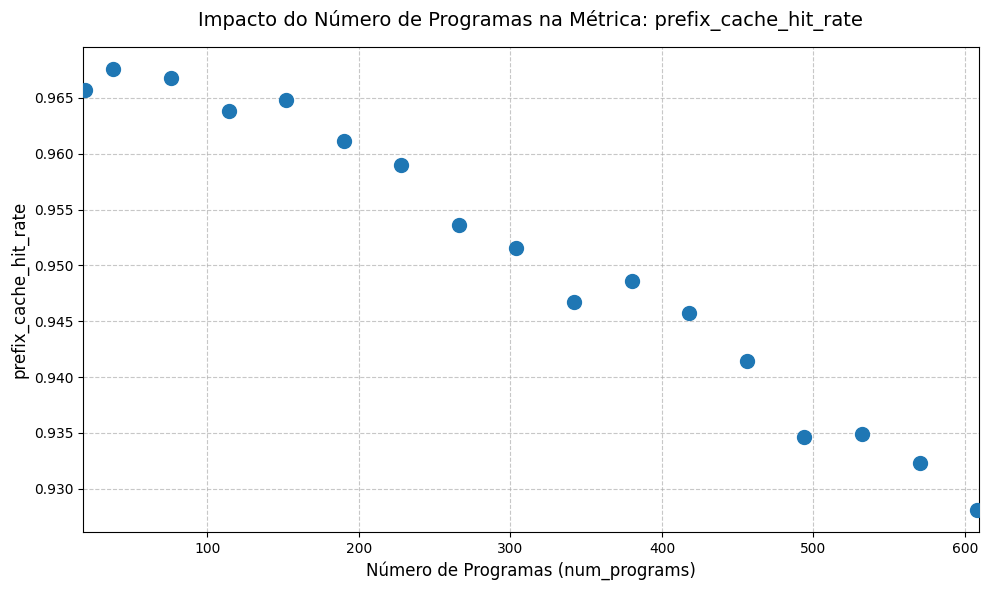

In [10]:
# Exemplo 1: Gerar gráfico para a métrica padrão (total_e2el_s)
# plotar_regressao("var_50it_mem", metrica="total_e2el_s")
# plotar_regressao("var_50it", metrica="total_e2el_s")


plotar_metricas_json("var_50it_nosleep", metrica="total_token_throughput")
plotar_metricas_json("var_50it_nosleep", metrica="total_output_tokens")
plotar_metricas_json("var_50it_nosleep", metrica="output_token_throughput")
plotar_metricas_json("var_50it_nosleep", metrica="total_e2el_s")
plotar_metricas_json("var_50it_nosleep", metrica="kv_cache_p75")

plotar_metricas_json("var_50it_nosleep", metrica="prefix_cache_hit_rate")

# plotar_regressao("var_50it_mem", metrica="total_e2el_s")
